In [84]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import tensorflow as tf

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Embedding,
    LSTM,
    Dense,
    Dropout,
    SpatialDropout1D
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

In [85]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("abdelmalekeladjelet/sentiment-analysis-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'sentiment-analysis-dataset' dataset.
Path to dataset files: /kaggle/input/sentiment-analysis-dataset


In [86]:
import os
# The correct data file name has been identified as 'sentiment_data.csv'
file_path = os.path.join(path, "sentiment_data.csv")
df = pd.read_csv(file_path)
df.head()

,Unnamed: 0,Comment,Sentiment
0,0,lets forget apple pay required brand new iphon...,1
1,1,nz retailers don’t even contactless credit car...,0
2,2,forever acknowledge channel help lessons ideas...,2
3,3,whenever go place doesn’t take apple pay doesn...,0
4,4,apple pay convenient secure easy use used kore...,2


In [87]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 241145 entries, 0 to 241144
Data columns (total 3 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   Unnamed: 0  241145 non-null  int64 
 1   Comment     240928 non-null  object
 2   Sentiment   241145 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 5.5+ MB


In [88]:
df.shape

(241145, 3)

In [89]:
print(df.isnull().sum())

Unnamed: 0      0
Comment       217
Sentiment       0
dtype: int64


In [90]:
df = df.dropna(subset=["Comment"])

print(df.shape)

(240928, 3)


In [91]:
df["Sentiment"].value_counts()

,count
Sentiment,
2,103046
1,82777
0,55105


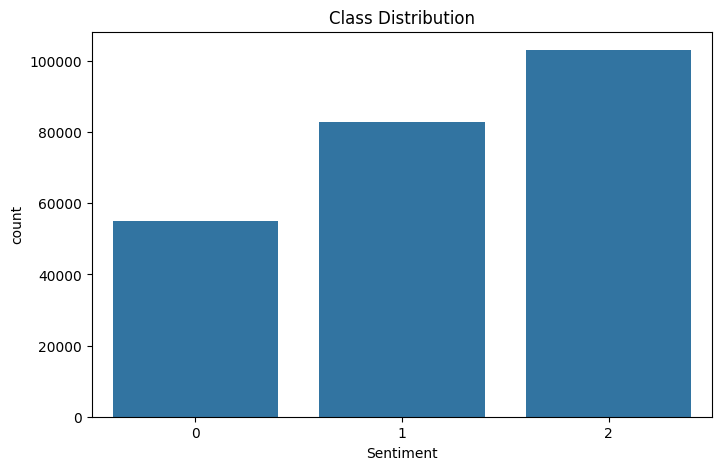

In [92]:
plt.figure(figsize=(8,5))

sns.countplot(
    x=df["Sentiment"]
)

plt.title("Class Distribution")
plt.show()

In [94]:
df = df.dropna(subset=["Comment"])

print(df.shape)

(240928, 3)


In [95]:
def clean_text(text):

    text = str(text)

    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"www\S+", "", text)
    text = re.sub(r"@\w+", "", text)

    text = re.sub(r"\s+", " ", text)

    return text.strip()

In [96]:
df["clean_text"] = df["Comment"].apply(clean_text)

In [97]:
X = df["clean_text"]

y = df["Sentiment"]

In [98]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [99]:
VOCAB_SIZE = 50000
MAX_LEN = 40

In [100]:
tokenizer = Tokenizer(
    num_words=VOCAB_SIZE,
    oov_token="<OOV>"
)

tokenizer.fit_on_texts(X_train)

In [101]:
X_train_seq = tokenizer.texts_to_sequences(X_train)

X_test_seq = tokenizer.texts_to_sequences(X_test)

In [102]:
X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

In [103]:
callbacks = [

    EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2
    ),

    ModelCheckpoint(
        "best_lstm.keras",
        save_best_only=True,
        monitor="val_loss"
    )

]

Build LSTM Model

In [104]:
lstm_model = Sequential([

    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=100
    ),

    SpatialDropout1D(0.2),

    LSTM(128),

    Dropout(0.3),

    Dense(64, activation="relu"),

    Dense(3, activation="softmax")

])

In [105]:
lstm_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [106]:
lstm_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_3             │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [107]:
history_lstm = lstm_model.fit(
    X_train_pad,
    y_train,
    validation_split=0.1,
    epochs=15,
    batch_size=256,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/15
678/678 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.7074 - loss: 0.7062 - val_accuracy: 0.8127 - val_loss: 0.5071 - learning_rate: 0.0010
Epoch 2/15
678/678 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/step - accuracy: 0.8428 - loss: 0.4382 - val_accuracy: 0.8347 - val_loss: 0.4514 - learning_rate: 0.0010
Epoch 3/15
678/678 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - accuracy: 0.8760 - loss: 0.3570 - val_accuracy: 0.8358 - val_loss: 0.4815 - learning_rate: 0.0010
Epoch 4/15
678/678 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.8976 - loss: 0.3033 - val_accuracy: 0.8425 - val_loss: 0.4652 - learning_rate: 0.0010
Epoch 5/15
678/678 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.9232 - loss: 0.2366 - val_accuracy: 0.8438 - val_loss: 0.4936 - learning_rate: 5.0000e-04


In [108]:
y_pred_prob_lstm = lstm_model.predict(X_test_pad)

y_pred_lstm = np.argmax(
    y_pred_prob_lstm,
    axis=1
)

1506/1506 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step


In [109]:
accuracy_lstm = accuracy_score(
    y_test,
    y_pred_lstm
)

precision_lstm = precision_score(
    y_test,
    y_pred_lstm,
    average="weighted"
)

recall_lstm = recall_score(
    y_test,
    y_pred_lstm,
    average="weighted"
)

f1_lstm = f1_score(
    y_test,
    y_pred_lstm,
    average="weighted"
)

In [110]:
print("Accuracy :", accuracy_lstm)
print("Precision:", precision_lstm)
print("Recall   :", recall_lstm)
print("F1 Score :", f1_lstm)

Accuracy : 0.8295355497447391
Precision: 0.8309116594894157
Recall   : 0.8295355497447391
F1 Score : 0.8299702417009175


In [111]:
print(
    classification_report(
        y_test,
        y_pred_lstm
    )
)

              precision    recall  f1-score   support

           0       0.76      0.78      0.77     11021
           1       0.81      0.84      0.83     16556
           2       0.88      0.85      0.87     20609

    accuracy                           0.83     48186
   macro avg       0.82      0.82      0.82     48186
weighted avg       0.83      0.83      0.83     48186



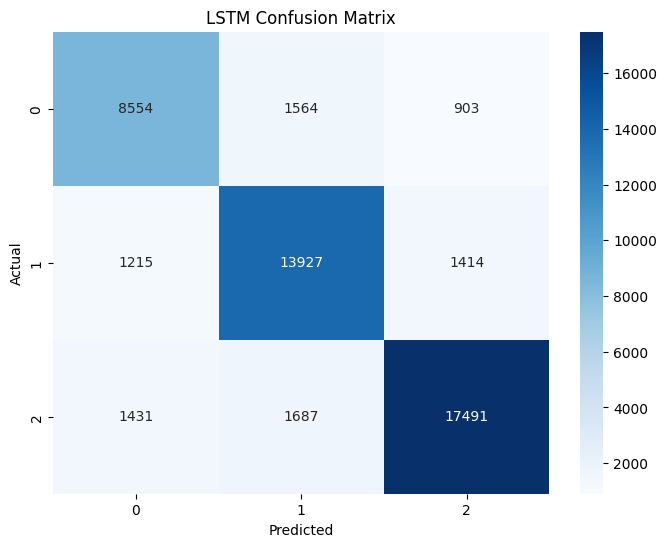

In [112]:
cm = confusion_matrix(
    y_test,
    y_pred_lstm
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("LSTM Confusion Matrix")

plt.show()

In [ ]:
from tensorflow.keras import backend as K

K.clear_session()

Build gru Model

In [122]:
gru_model = Sequential([

    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=100
    ),

    SpatialDropout1D(0.2),

    GRU(128),

    Dropout(0.3),

    Dense(64, activation="relu"),

    Dense(3, activation="softmax")

])

In [123]:
gru_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [124]:
gru_model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_5             │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_3 (GRU)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [125]:
callbacks_gru = [

    EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2
    ),

    ModelCheckpoint(
        "best_gru.keras",
        save_best_only=True,
        monitor="val_loss"
    )
]

In [126]:
history_gru = gru_model.fit(
    X_train_pad,
    y_train,
    validation_split=0.1,
    epochs=15,
    batch_size=256,
    callbacks=callbacks_gru,
    verbose=1
)

Epoch 1/15
678/678 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - accuracy: 0.4268 - loss: 1.0691 - val_accuracy: 0.4360 - val_loss: 1.0643 - learning_rate: 0.0010
Epoch 2/15
678/678 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.7379 - loss: 0.6441 - val_accuracy: 0.8320 - val_loss: 0.4501 - learning_rate: 0.0010
Epoch 3/15
678/678 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.8563 - loss: 0.3963 - val_accuracy: 0.8480 - val_loss: 0.4247 - learning_rate: 0.0010
Epoch 4/15
678/678 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.8920 - loss: 0.3094 - val_accuracy: 0.8496 - val_loss: 0.4332 - learning_rate: 0.0010
Epoch 5/15
678/678 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.9182 - loss: 0.2431 - val_accuracy: 0.8524 - val_loss: 0.4665 - learning_rate: 0.0010
Epoch 6/15
678/678 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.9417 - loss: 0.1789 - val_accuracy: 0.8492 - val_loss: 0.5455 - learning_rate: 5.0000e-04


In [127]:
len(history_gru.history["loss"])

6

In [128]:
history_gru.history["val_accuracy"]

[0.436005175113678,
 0.8320103883743286,
 0.8480414748191833,
 0.8496497869491577,
 0.852399468421936,
 0.8491829037666321]

In [129]:
y_pred_prob_gru = gru_model.predict(X_test_pad)

y_pred_gru = np.argmax(
    y_pred_prob_gru,
    axis=1
)

1506/1506 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step


In [130]:
accuracy_gru = accuracy_score(
    y_test,
    y_pred_gru
)

precision_gru = precision_score(
    y_test,
    y_pred_gru,
    average="weighted"
)

recall_gru = recall_score(
    y_test,
    y_pred_gru,
    average="weighted"
)

f1_gru = f1_score(
    y_test,
    y_pred_gru,
    average="weighted"
)

In [131]:
print("Accuracy :", accuracy_gru)
print("Precision:", precision_gru)
print("Recall   :", recall_gru)
print("F1 Score :", f1_gru)

Accuracy : 0.845971859046196
Precision: 0.8471437026646611
Recall   : 0.845971859046196
F1 Score : 0.8460639563534207


In [132]:
print(
    classification_report(
        y_test,
        y_pred_gru
    )
)

              precision    recall  f1-score   support

           0       0.80      0.78      0.79     11021
           1       0.81      0.87      0.84     16556
           2       0.90      0.86      0.88     20609

    accuracy                           0.85     48186
   macro avg       0.84      0.84      0.84     48186
weighted avg       0.85      0.85      0.85     48186



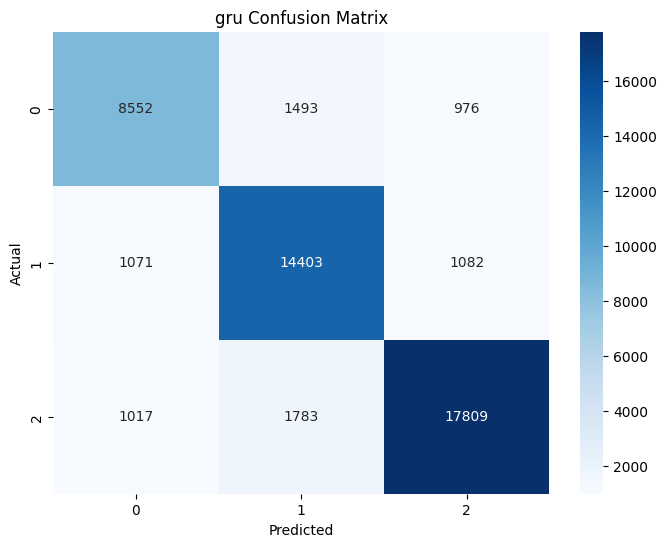

In [134]:
cm2 = confusion_matrix(
    y_test,
    y_pred_gru
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm2,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("gru Confusion Matrix")

plt.show()

Although LSTM is often considered more expressive due to its additional memory cell,
GRU achieved better performance on this dataset while requiring fewer parameters and faster training time.

In [136]:
from tensorflow.keras import backend as K

K.clear_session()

BiLSTM

In [135]:
callbacks_bilstm = [
    EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2
    ),

    ModelCheckpoint(
        "best_bilstm.keras",
        save_best_only=True
    )
]

In [137]:
from tensorflow.keras.layers import Bidirectional

In [138]:
bilstm_model = Sequential([

    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=100
    ),

    SpatialDropout1D(0.2),

    Bidirectional(
        LSTM(128)
    ),

    Dropout(0.3),

    Dense(64, activation="relu"),

    Dense(3, activation="softmax")

])

In [139]:
bilstm_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [140]:
history_bilstm = bilstm_model.fit(
    X_train_pad,
    y_train,
    validation_split=0.1,
    epochs=15,
    batch_size=256,
    callbacks=callbacks_bilstm,
    verbose=1
)

Epoch 1/15
678/678 ━━━━━━━━━━━━━━━━━━━━ 20s 24ms/step - accuracy: 0.7519 - loss: 0.6119 - val_accuracy: 0.8305 - val_loss: 0.4524 - learning_rate: 0.0010
Epoch 2/15
678/678 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/step - accuracy: 0.8566 - loss: 0.3917 - val_accuracy: 0.8450 - val_loss: 0.4314 - learning_rate: 0.0010
Epoch 3/15
678/678 ━━━━━━━━━━━━━━━━━━━━ 12s 18ms/step - accuracy: 0.8866 - loss: 0.3194 - val_accuracy: 0.8427 - val_loss: 0.4415 - learning_rate: 0.0010
Epoch 4/15
678/678 ━━━━━━━━━━━━━━━━━━━━ 12s 18ms/step - accuracy: 0.9069 - loss: 0.2640 - val_accuracy: 0.8457 - val_loss: 0.4720 - learning_rate: 0.0010
Epoch 5/15
678/678 ━━━━━━━━━━━━━━━━━━━━ 13s 19ms/step - accuracy: 0.9322 - loss: 0.1970 - val_accuracy: 0.8476 - val_loss: 0.5292 - learning_rate: 5.0000e-04


In [141]:
y_pred_prob_bilstm = bilstm_model.predict(X_test_pad)

y_pred_bilstm = np.argmax(
    y_pred_prob_bilstm,
    axis=1
)

1506/1506 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step


In [146]:
comparison_df = pd.DataFrame({

    "Model":[
        "LSTM",
        "GRU",
        "BiLSTM"
    ],

    "Accuracy":[
        accuracy_lstm,
        accuracy_gru,
        accuracy_bilstm
    ],

    "Precision":[
        precision_lstm,
        precision_gru,
        precision_bilstm
    ],

    "Recall":[
        recall_lstm,
        recall_gru,
        recall_bilstm
    ],

    "F1":[
        f1_lstm,
        f1_gru,
        f1_bilstm
    ]

})

comparison_df.sort_values(
    by="F1",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1
1,GRU,0.845972,0.847144,0.845972,0.846064
2,BiLSTM,0.839954,0.839966,0.839954,0.839369
0,LSTM,0.829536,0.830912,0.829536,0.829970


# Conclusion

Three recurrent neural network architectures were evaluated for multiclass sentiment classification.

GRU achieved the highest overall performance with an F1-score of 84.61%, outperforming both LSTM and Bidirectional LSTM.

The results suggest that for relatively short text sequences, GRU can provide an excellent trade-off between computational efficiency and predictive performance.

Future work may include:
- Pretrained embeddings (GloVe / FastText)
- Transformer-based models (BERT)
- Hyperparameter optimization
- Attention mechanisms